# Unit 2 Case Study — IEEE-CIS Fraud Detection

Random Forest is trained on imbalanced transaction data. An RBF SVM is demonstrated on a non-separable two-moons dataset with a decision-boundary plot. XGBoost is trained on IEEE-CIS data with SMOTE, threshold tuning is performed using F1, feature importance is shown, and results are compared with a baseline SVM.

In [1]:
import os, glob, warnings
warnings.filterwarnings("ignore")
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.datasets import make_moons
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

path = kagglehub.dataset_download("lnasiri007/ieeecis-fraud-detection")
path = next(x for x in glob.glob(os.path.join(path, "**", "train_transaction.csv"), recursive=True))

chunks = []
for c in pd.read_csv(path, chunksize=100000):
    chunks.append(c.sample(min(len(c), 30000), random_state=42))
    if len(chunks) * 30000 >= 150000:
        break
df = pd.concat(chunks, ignore_index=True)
df.shape


100%|██████████| 118M/118M [00:06<00:00, 19.5MB/s]

Extracting files...


(150000, 394)

In [2]:
y = df.pop("isFraud").astype(int)
X = df.drop(columns=["TransactionID"], errors="ignore")
cat = X.select_dtypes(exclude=np.number).columns
X[cat] = X[cat].apply(lambda s: pd.factorize(s)[0])
X = X.replace([np.inf, -np.inf], np.nan)
X = SimpleImputer(strategy="median").fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, stratify=y, random_state=42)
print("Fraud rate:", round(y.mean(), 4))

Fraud rate: 0.0348


In [3]:
rf = RandomForestClassifier(n_estimators=150, max_depth=12, class_weight="balanced", n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
rf_p = rf.predict_proba(X_test)[:,1]
rf_pred = (rf_p >= .5).astype(int)
print("Random Forest ROC-AUC:", round(roc_auc_score(y_test, rf_p), 4))
print("Precision:", round(precision_score(y_test, rf_pred), 4), "Recall:", round(recall_score(y_test, rf_pred), 4), "F1:", round(f1_score(y_test, rf_pred), 4))

Random Forest ROC-AUC: 0.881
Precision: 0.2461 Recall: 0.6385 F1: 0.3553


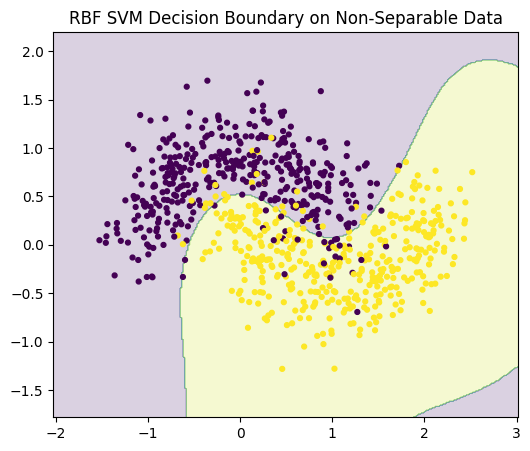

In [4]:
moon_X, moon_y = make_moons(n_samples=800, noise=.28, random_state=42)
mx1, mx2, my1, my2 = train_test_split(moon_X, moon_y, test_size=.25, random_state=42, stratify=moon_y)
svm = SVC(kernel="rbf", C=2, gamma="scale")
svm.fit(mx1, my1)
xx, yy = np.meshgrid(np.linspace(moon_X[:,0].min()-.5, moon_X[:,0].max()+.5, 300), np.linspace(moon_X[:,1].min()-.5, moon_X[:,1].max()+.5, 300))
zz = svm.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.figure(figsize=(6,5))
plt.contourf(xx, yy, zz, alpha=.2)
plt.scatter(moon_X[:,0], moon_X[:,1], c=moon_y, s=12)
plt.title("RBF SVM Decision Boundary on Non-Separable Data")
plt.show()

In [5]:
sm = SMOTE(random_state=42)
Xs, ys = sm.fit_resample(X_train, y_train)
scale = StandardScaler()
Xs_s = scale.fit_transform(Xs)
Xt_s = scale.transform(X_test)

svm_base = SVC(kernel="rbf", C=1, gamma="scale", probability=True, random_state=42)
svm_base.fit(Xs_s[:min(20000,len(Xs_s))], ys[:min(20000,len(ys))])
svm_p = svm_base.predict_proba(Xt_s)[:,1]

pos = max(1, int((y_train == 1).sum()))
neg = int((y_train == 0).sum())
xgb = XGBClassifier(n_estimators=180, max_depth=6, learning_rate=.08, subsample=.8, colsample_bytree=.8, scale_pos_weight=neg/pos, eval_metric="logloss", tree_method="hist", n_jobs=-1, random_state=42)
xgb.fit(Xs, ys)
xgb_p = xgb.predict_proba(X_test)[:,1]

def metrics(p, t=.5):
    q = (p >= t).astype(int)
    return [roc_auc_score(y_test,p), precision_score(y_test,q,zero_division=0), recall_score(y_test,q,zero_division=0), f1_score(y_test,q,zero_division=0)]

ts = np.arange(.05,.96,.05)
best_t = max(ts, key=lambda t: metrics(xgb_p,t)[3])
results = pd.DataFrame([metrics(svm_p), metrics(xgb_p), metrics(xgb_p,best_t)], index=["Baseline SVM","XGBoost @ 0.50",f"XGBoost @ {best_t:.2f}"], columns=["ROC-AUC","Precision","Recall","F1"])
results.round(4)

,ROC-AUC,Precision,Recall,F1
Baseline SVM,0.7816,0.7412,0.2224,0.3422
XGBoost @ 0.50,0.9108,0.2114,0.7728,0.3320
XGBoost @ 0.90,0.9108,0.6574,0.4765,0.5525


In [6]:
cm = confusion_matrix(y_test, (xgb_p >= best_t).astype(int))
print("Best XGBoost threshold:", round(best_t,2))
print(cm)
print(classification_report(y_test, (xgb_p >= best_t).astype(int), digits=4, zero_division=0))

Best XGBoost threshold: 0.9
[[28698   259]
 [  546   497]]
              precision    recall  f1-score   support

           0     0.9813    0.9911    0.9862     28957
           1     0.6574    0.4765    0.5525      1043

    accuracy                         0.9732     30000
   macro avg     0.8194    0.7338    0.7693     30000
weighted avg     0.9701    0.9732    0.9711     30000



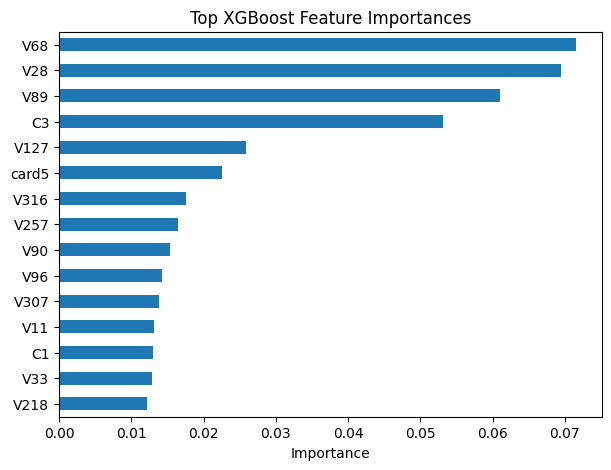

In [7]:
imp = pd.Series(xgb.feature_importances_).sort_values(ascending=False).head(15)
imp.index = df.columns[imp.index]
imp.sort_values().plot.barh(figsize=(7,5))
plt.title("Top XGBoost Feature Importances")
plt.xlabel("Importance")
plt.show()